In [1]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def parse_mums_file(filepath, label):
    """
    Parses a .mums file.
    - length: 1st column
    - present_count: number of non-empty values in 2nd column
    """
    data = []
    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) < 2:
                continue
            
            # 1st column is the length of the MUM
            length = int(parts[0])
            
            # 2nd column contains comma-separated indices/values
            # We count only the non-empty entries
            presence_list = [x.strip() for x in parts[1].split(',') if x.strip() != '']
            present_count = len(presence_list)
            
            is_consistent = 1 if len(set(presence_list)) == 1 else 0


            data.append({
                'Length': length,
                'Present_Count': present_count,
                'Location_Consistency': is_consistent,
                'Dataset': label
            })
    return pd.DataFrame(data)

def calculate_n50(lengths):
    if len(lengths) == 0: return 0
    sorted_lengths = np.sort(lengths)[::-1]
    total_sum = np.sum(sorted_lengths)
    cumulative_sum = np.cumsum(sorted_lengths)
    return sorted_lengths[np.where(cumulative_sum >= total_sum / 2)[0][0]]

In [3]:
base_path = "/home/Users/rdd4/mft-analyses/Figure3/data"
all_data = []

# 1. Identify all alpha folders
# This assumes folder names are like 'n_2', 'n_5', etc.
n_folders = [f for f in os.listdir(base_path) if f.startswith('n_')]

for folder_name in n_folders:
    # Extract the numerical value of alpha for easier plotting later
    try:
        alpha_val = float(folder_name.split('_')[1])
    except:
        alpha_val = folder_name # Fallback to string if naming is weird
        
    folder_full_path = os.path.join(base_path, folder_name)
    
    # 2. Define the files we expect in each folder
    # Format: (filename, label/w_value)
    target_files = [
        ('nucleotide.mums', 'Nucleotide'),
        ('mft_w5.mums', 'MFT (w=5)'),
        ('mft_w8.mums', 'MFT (w=8)'),
        ('mft_w11.mums', 'MFT (w=11)')
    ]
    
    for filename, w_label in target_files:
        filepath = os.path.join(folder_full_path, filename)
        
        if os.path.exists(filepath):
            # Use your existing parsing function
            temp_df = parse_mums_file(filepath, w_label)
            
            # Add the alpha metadata to every row
            temp_df['Alpha'] = alpha_val
            
            all_data.append(temp_df)
        else:
            print(f"Warning: {filepath} not found.")

# 3. Combine everything into one master DataFrame
df_master = pd.concat(all_data, ignore_index=True)
df_master

,Length,Present_Count,Location_Consistency,Dataset,Alpha
0,21,8,1,Nucleotide,10.0
1,22,10,1,Nucleotide,10.0
2,223,3,1,Nucleotide,10.0
3,51,4,1,Nucleotide,10.0
4,36,5,1,Nucleotide,10.0
...,...,...,...,...,...
9315770,105,12,1,MFT (w=11),20.0
9315771,92,13,1,MFT (w=11),20.0
9315772,33,14,1,MFT (w=11),20.0
9315773,26,2,0,MFT (w=11),20.0


In [4]:
## Due to bug/feature of mumemto in that the short sequences can sometimes lead to MUMs that are much longer than the actual sequence, we filter out MUMs longer than 10,000 bp for the analysis. This is a very conservative threshold and should not affect the results since most MUMs are expected to be much shorter than this.

df_final = df_master[df_master['Length'] <= 10000]
df_final['Alpha'] = df_final['Alpha'].astype(int)
df_final['Present_Fraction'] = df_final['Present_Count'] / df_final['Alpha']
df_final

,Length,Present_Count,Location_Consistency,Dataset,Alpha,Present_Fraction
0,21,8,1,Nucleotide,10,0.80
1,22,10,1,Nucleotide,10,1.00
2,223,3,1,Nucleotide,10,0.30
3,51,4,1,Nucleotide,10,0.40
4,36,5,1,Nucleotide,10,0.50
...,...,...,...,...,...,...
9315770,105,12,1,MFT (w=11),20,0.60
9315771,92,13,1,MFT (w=11),20,0.65
9315772,33,14,1,MFT (w=11),20,0.70
9315773,26,2,0,MFT (w=11),20,0.10


In [5]:
summary_df = df_final.groupby(['Alpha', 'Dataset']).apply(
    lambda x: pd.Series({
        'N50': calculate_n50(x['Length'].values),
        'Total_MUMs': len(x)
    })
).reset_index()

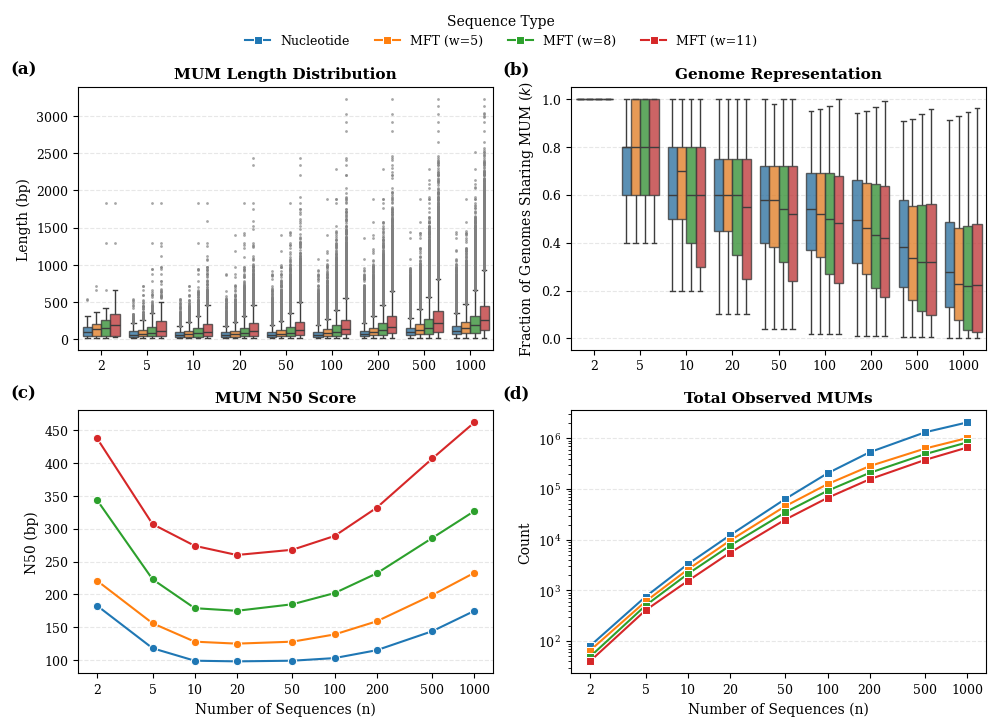

In [17]:
from matplotlib.ticker import FixedLocator, FixedFormatter

# 1. Academic Styling Setup
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Times"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

custom_ticks = [2, 5, 10, 20, 50, 100, 200, 500, 1000]
custom_tick_labels = [str(t) for t in custom_ticks]

# Define shared order and parameters
hue_order = ['Nucleotide', 'MFT (w=5)', 'MFT (w=8)', 'MFT (w=11)']
flierprops = dict(marker='o', markersize=2, alpha=0.7, markeredgecolor='none', markerfacecolor='gray')

# 2. Create Figure (Standard column width ~10 inches)
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

# --- (a) TOP LEFT: MUM Length ---
ax = axes[0, 0]
sns.boxplot(data=df_final, x='Alpha', y='Length', hue='Dataset', hue_order=hue_order,
            ax=ax, flierprops=flierprops, palette="tab10", boxprops={'alpha': 0.8})
ax.set_title('MUM Length Distribution', fontweight='bold')
ax.set_ylabel('Length (bp)')
ax.set_xlabel('')

# --- (b) TOP RIGHT: Genomes Count ---
ax = axes[0, 1]
sns.boxplot(data=df_final, x='Alpha', y='Present_Fraction', hue='Dataset', hue_order=hue_order,
            ax=ax, flierprops=flierprops, palette="tab10", boxprops={'alpha': 0.8})
ax.set_title('Genome Representation', fontweight='bold')
ax.set_ylabel('Fraction of Genomes Sharing MUM ($k$)')
ax.set_xlabel('')

# --- (c) BOTTOM LEFT: N50 ---
ax = axes[1, 0]
sns.lineplot(data=summary_df, x='Alpha', y='N50', hue='Dataset', hue_order=hue_order,
             ax=ax, marker='o', palette="tab10", markersize=6, linewidth=1.5)
ax.set_title('MUM N50 Score', fontweight='bold')
ax.set_ylabel('N50 (bp)')
ax.set_xscale('log')
ax.set_xlabel(r'Number of Sequences (n)')
ax.xaxis.set_major_locator(FixedLocator(custom_ticks))
ax.xaxis.set_major_formatter(FixedFormatter(custom_tick_labels))
ax.xaxis.set_minor_locator(plt.NullLocator())

# --- (d) BOTTOM RIGHT: Total MUMs ---
ax = axes[1, 1]
sns.lineplot(data=summary_df, x='Alpha', y='Total_MUMs', hue='Dataset', hue_order=hue_order,
             ax=ax, marker='s', palette="tab10", markersize=6, linewidth=1.5)
ax.set_title('Total Observed MUMs', fontweight='bold')
ax.set_ylabel('Count')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel(r'Number of Sequences (n)')
ax.xaxis.set_major_locator(FixedLocator(custom_ticks))
ax.xaxis.set_major_formatter(FixedFormatter(custom_tick_labels))
ax.xaxis.set_minor_locator(plt.NullLocator())

# 3. Final Polishing
subplot_labels = ['a', 'b', 'c', 'd']
for i, ax in enumerate(axes.flat):
    # Add (a), (b), (c), (d) labels
    ax.text(-0.1, 1.1, f'({subplot_labels[i]})', transform=ax.transAxes, 
            fontsize=12, fontweight='bold', va='top', ha='right')
    
    # Consistent Grid
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Remove internal legends
    if ax.get_legend():
        ax.get_legend().remove()

# 4. Global Legend (Top Center/Right)
handles, labels = axes[1, 1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.04), 
           ncol=4, frameon=False, title="Sequence Type")

plt.tight_layout()
# Adjust to make room for top legend
plt.subplots_adjust(top=0.92) 

plt.savefig('Figure3.png', dpi=300, bbox_inches='tight')
plt.savefig('Figure3.svg', dpi=300, bbox_inches='tight')
plt.savefig('Figure3.pdf', dpi=300, bbox_inches='tight')

plt.show()


In [9]:
df_final.groupby(['Alpha', 'Dataset'])['Location_Consistency'].value_counts().unstack(fill_value=0)

Location_Consistency      0        1
Alpha Dataset                       
2     MFT (w=11)          9       31
      MFT (w=5)           0       65
      MFT (w=8)           7       42
      Nucleotide          0       80
5     MFT (w=11)         95      312
      MFT (w=5)           1      606
      MFT (w=8)          63      442
      Nucleotide          0      754
10    MFT (w=11)        366     1168
      MFT (w=5)           2     2582
      MFT (w=8)         284     1826
      Nucleotide          0     3294
20    MFT (w=11)       1115     4416
      MFT (w=5)           5     9577
      MFT (w=8)         947     6664
      Nucleotide          0    12204
50    MFT (w=11)       3936    21208
      MFT (w=5)          27    46223
      MFT (w=8)        3561    31334
      Nucleotide          0    64178
100   MFT (w=11)       9046    58164
      MFT (w=5)          82   125389
      MFT (w=8)        8626    84064
      Nucleotide          0   205249
200   MFT (w=11)      18213   138094
      MFT (w=5)         225   284098
      MFT (w=8)       17000   192098
      Nucleotide          0   534136
500   MFT (w=11)      33789   344283
      MFT (w=5)         620   632727
      MFT (w=8)       32494   459139
      Nucleotide          0  1325605
1000  MFT (w=11)      47877   615682
      MFT (w=5)        1107  1019234
      MFT (w=8)       46222   791943
      Nucleotide          0  2073145

In [19]:
df_final[(df_final['Length'] > 50)].groupby(['Alpha', 'Dataset'])['Location_Consistency'].value_counts().unstack(fill_value=0)

Location_Consistency      0        1
Alpha Dataset                       
2     MFT (w=11)          0       29
      MFT (w=5)           0       49
      MFT (w=8)           0       37
      Nucleotide          0       55
5     MFT (w=11)         12      284
      MFT (w=5)           0      409
      MFT (w=8)           0      351
      Nucleotide          0      462
10    MFT (w=11)         49     1040
      MFT (w=5)           0     1630
      MFT (w=8)           0     1407
      Nucleotide          0     1815
20    MFT (w=11)        161     4011
      MFT (w=5)           0     6139
      MFT (w=8)           1     5188
      Nucleotide          0     6806
50    MFT (w=11)        682    19559
      MFT (w=5)           0    31186
      MFT (w=8)           5    25343
      Nucleotide          0    37153
100   MFT (w=11)       1757    54610
      MFT (w=5)           0    89464
      MFT (w=8)          10    70313
      Nucleotide          0   125190
200   MFT (w=11)       3921   131699
      MFT (w=5)           0   217844
      MFT (w=8)          25   166653
      Nucleotide          0   356934
500   MFT (w=11)       8238   333246
      MFT (w=5)           0   529861
      MFT (w=8)          70   415469
      Nucleotide          0  1027729
1000  MFT (w=11)      12958   601063
      MFT (w=5)           0   887955
      MFT (w=8)         121   733097
      Nucleotide          0  1741435

In [18]:
df_final[(df_final['Length'] > 50) & (df_final['Present_Count'] > 2)].groupby(['Alpha', 'Dataset'])['Location_Consistency'].value_counts().unstack(fill_value=0)

Location_Consistency      0        1
Alpha Dataset                       
5     MFT (w=11)          7      230
      MFT (w=5)           0      318
      MFT (w=8)           0      282
      Nucleotide          0      349
10    MFT (w=11)         17      981
      MFT (w=5)           0     1511
      MFT (w=8)           0     1325
      Nucleotide          0     1680
20    MFT (w=11)         64     3906
      MFT (w=5)           0     5995
      MFT (w=8)           0     5055
      Nucleotide          0     6670
50    MFT (w=11)        422    19117
      MFT (w=5)           0    30713
      MFT (w=8)           3    24826
      Nucleotide          0    36804
100   MFT (w=11)       1342    53292
      MFT (w=5)           0    87859
      MFT (w=8)           6    68668
      Nucleotide          0   124078
200   MFT (w=11)       3368   128376
      MFT (w=5)           0   212927
      MFT (w=8)          18   162198
      Nucleotide          0   353070
500   MFT (w=11)       7572   324590
      MFT (w=5)           0   511908
      MFT (w=8)          62   402444
      Nucleotide          0  1009822
1000  MFT (w=11)      12173   585240
      MFT (w=5)           0   849269
      MFT (w=8)         101   708482
      Nucleotide          0  1696411

In [20]:
df_final_filtered = df_final[(df_final['Location_Consistency'] == 1)]
summary_df_filtered = df_final_filtered.groupby(['Alpha', 'Dataset']).apply(
    lambda x: pd.Series({
        'N50': calculate_n50(x['Length'].values),
        'Total_MUMs': len(x)
    })
).reset_index()

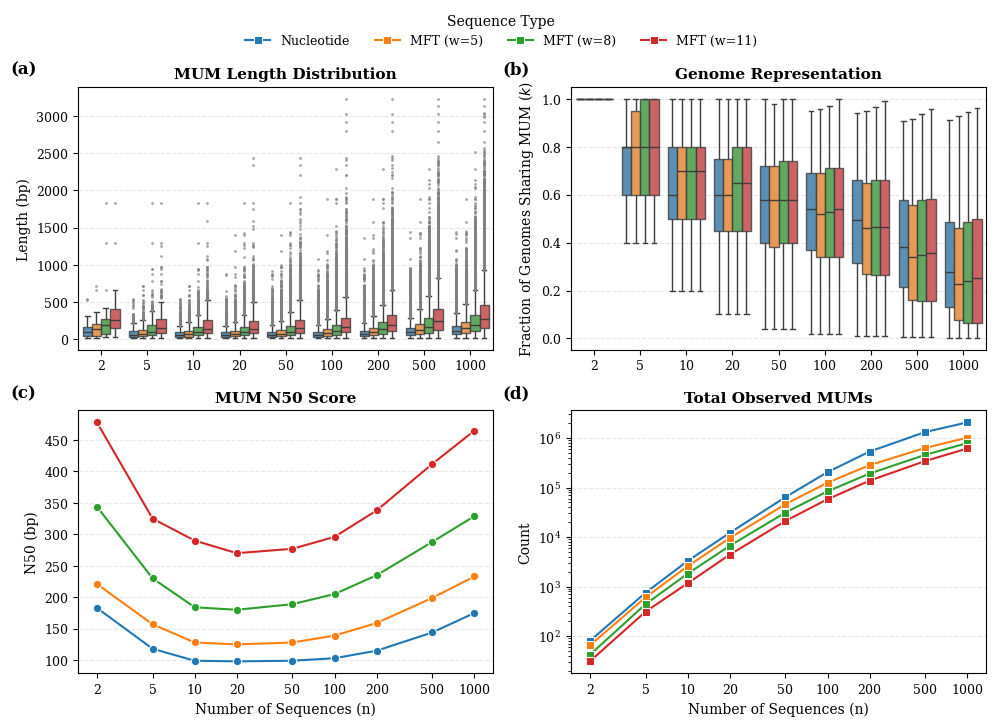

In [21]:
from matplotlib.ticker import FixedLocator, FixedFormatter

# 1. Academic Styling Setup
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Times"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

custom_ticks = [2, 5, 10, 20, 50, 100, 200, 500, 1000]
custom_tick_labels = [str(t) for t in custom_ticks]

# Define shared order and parameters
hue_order = ['Nucleotide', 'MFT (w=5)', 'MFT (w=8)', 'MFT (w=11)']
flierprops = dict(marker='o', markersize=2, alpha=0.7, markeredgecolor='none', markerfacecolor='gray')

# 2. Create Figure (Standard column width ~10 inches)
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

# --- (a) TOP LEFT: MUM Length ---
ax = axes[0, 0]
sns.boxplot(data=df_final_filtered, x='Alpha', y='Length', hue='Dataset', hue_order=hue_order,
            ax=ax, flierprops=flierprops, palette="tab10", boxprops={'alpha': 0.8})
ax.set_title('MUM Length Distribution', fontweight='bold')
ax.set_ylabel('Length (bp)')
ax.set_xlabel('')

# --- (b) TOP RIGHT: Genomes Count ---
ax = axes[0, 1]
sns.boxplot(data=df_final_filtered, x='Alpha', y='Present_Fraction', hue='Dataset', hue_order=hue_order,
            ax=ax, flierprops=flierprops, palette="tab10", boxprops={'alpha': 0.8})
ax.set_title('Genome Representation', fontweight='bold')
ax.set_ylabel('Fraction of Genomes Sharing MUM ($k$)')
ax.set_xlabel('')

# --- (c) BOTTOM LEFT: N50 ---
ax = axes[1, 0]
sns.lineplot(data=summary_df_filtered, x='Alpha', y='N50', hue='Dataset', hue_order=hue_order,
             ax=ax, marker='o', palette="tab10", markersize=6, linewidth=1.5)
ax.set_title('MUM N50 Score', fontweight='bold')
ax.set_ylabel('N50 (bp)')
ax.set_xscale('log')
ax.set_xlabel(r'Number of Sequences (n)')
ax.xaxis.set_major_locator(FixedLocator(custom_ticks))
ax.xaxis.set_major_formatter(FixedFormatter(custom_tick_labels))
ax.xaxis.set_minor_locator(plt.NullLocator())

# --- (d) BOTTOM RIGHT: Total MUMs ---
ax = axes[1, 1]
sns.lineplot(data=summary_df_filtered, x='Alpha', y='Total_MUMs', hue='Dataset', hue_order=hue_order,
             ax=ax, marker='s', palette="tab10", markersize=6, linewidth=1.5)
ax.set_title('Total Observed MUMs', fontweight='bold')
ax.set_ylabel('Count')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel(r'Number of Sequences (n)')
ax.xaxis.set_major_locator(FixedLocator(custom_ticks))
ax.xaxis.set_major_formatter(FixedFormatter(custom_tick_labels))
ax.xaxis.set_minor_locator(plt.NullLocator())

# 3. Final Polishing
subplot_labels = ['a', 'b', 'c', 'd']
for i, ax in enumerate(axes.flat):
    # Add (a), (b), (c), (d) labels
    ax.text(-0.1, 1.1, f'({subplot_labels[i]})', transform=ax.transAxes, 
            fontsize=12, fontweight='bold', va='top', ha='right')
    
    # Consistent Grid
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Remove internal legends
    if ax.get_legend():
        ax.get_legend().remove()

# 4. Global Legend (Top Center/Right)
handles, labels = axes[1, 1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.04), 
           ncol=4, frameon=False, title="Sequence Type")

plt.tight_layout()
# Adjust to make room for top legend
plt.subplots_adjust(top=0.92) 

plt.savefig('Figure3_filtered.png', dpi=300, bbox_inches='tight')
plt.savefig('Figure3_filtered.svg', dpi=300, bbox_inches='tight')
plt.savefig('Figure3_filtered.pdf', dpi=300, bbox_inches='tight')

plt.show()